# Stage 32 — M4 Diagnostic (CT)

**Hypothesis (RQ13):** The max-gap filter on plain M4 purity correctly and automatically
selects L3+L4, without any hardcoded threshold.

**Pipeline role:** Phase 1 of the v8 two-phase pipeline.
- Load `proto_seg_ct_pp2.pth` (plain M4, ep=90, val=0.8238, no attention)
- Verify 3D Dice ≥ 0.82 (acceptance criterion for reuse)
- Compute per-level purity on training set for all 4 levels
- Apply max-gap filter → confirm L3+L4 auto-selected
- Answer RQ13

**Why plain M4 (no attention):** Attention model has an L2 feedback loop
(`w_L2 → soft_mask → decoder → seg_loss → ∇w_L2 → encoder`) that can
artificially inflate L2 purity. Plain M4 gives a cleaner signal.

## 0. Config

In [ ]:
import sys, os

_root = (
    os.path.dirname(os.getcwd())
    if os.path.basename(os.getcwd()) == "notebooks"
    else os.getcwd()
)
os.chdir(_root)
sys.path.insert(0, _root)
os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

# ── Diagnostic checkpoint (plain M4, no attention) ────────────────────────────
DIAG_CKPT = "checkpoints/proto_seg_ct_pp2.pth"
MODALITY = "ct"

# ── Acceptance criteria ───────────────────────────────────────────────────────
MIN_3D_DICE = 0.82

# ── Outputs ──────────────────────────────────────────────────────────────────
DATA_DIR = "data/pack/processed_data"
LOG_DIR = "results/v8"

import pathlib

pathlib.Path(LOG_DIR).mkdir(parents=True, exist_ok=True)

PURITY_CSV = f"{LOG_DIR}/purity_m4_plain_ct.csv"

print(f"Diagnostic checkpoint : {DIAG_CKPT}")
print(f"Acceptance criterion  : 3D Dice ≥ {MIN_3D_DICE}")
print(f"Output                : {PURITY_CSV}")

Diagnostic checkpoint : checkpoints/proto_seg_ct_pp2.pth
Acceptance criterion  : 3D Dice ≥ 0.82
Output                : results/v8/purity_m4_plain_ct.csv


## 1. Imports & Device

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.data.mmwhs_dataset import (
    MMWHSSliceDataset,
    MMWHSPatientDataset,
    LABEL_NAMES,
    NUM_CLASSES,
)
from src.models.proto_seg_net import ProtoSegNet
from src.metrics.dice import dice_per_class, mean_foreground_dice
from src.metrics.proto_quality import compute_purity

DEVICE = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)
FG_NAMES = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]
print(f"Device: {DEVICE}")

Device: mps


## 2. Load & Verify Checkpoint

Acceptance criteria for reuse without retraining:
- `levels=None` (= all 4 levels active)
- `attn=None` or `use_level_attention=False` (plain M4, no attention)
- 3D test Dice ≥ 0.82

In [3]:
ckpt = torch.load(DIAG_CKPT, map_location="cpu", weights_only=False)

saved_levels = ckpt.get("proto_levels", None)
saved_attn = ckpt.get("use_level_attention", None)
saved_epoch = ckpt.get("epoch", "?")
saved_val = ckpt.get("best_val_dice", float("nan"))

print(f"Checkpoint    : {DIAG_CKPT}")
print(f"Epoch         : {saved_epoch}")
print(f"Val Dice      : {saved_val:.4f}")
print(f"proto_levels  : {saved_levels}  (None = all 4 levels)")
print(f"use_attn      : {saved_attn}")

# Acceptance check: levels
ok_levels = saved_levels is None or set(saved_levels) == {1, 2, 3, 4}
ok_attn = not saved_attn  # None or False both acceptable

print()
print(f"Levels check (all 4): {'✅' if ok_levels else '❌ FAIL — retrain needed'}")
print(f"Attention check (none): {'✅' if ok_attn else '❌ FAIL — use plain M4'}")

assert ok_levels, "Checkpoint must have all 4 levels!"
assert ok_attn, "Checkpoint must be a plain M4 (no attention)!"

# Build model from checkpoint
proto_levels = saved_levels if saved_levels is not None else [1, 2, 3, 4]
model = ProtoSegNet(
    n_classes=NUM_CLASSES,
    proto_levels=proto_levels,
    use_level_attention=False,
).to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print(
    f"\nModel loaded. proto_levels={model.proto_levels}  use_attn={model.use_level_attention}"
)
print(f"Total params: {model.count_parameters()['total']:,}")

Checkpoint    : checkpoints/proto_seg_ct_pp2.pth
Epoch         : 90
Val Dice      : 0.8238
proto_levels  : None  (None = all 4 levels)
use_attn      : None

Levels check (all 4): ✅
Attention check (none): ✅

Model loaded. proto_levels=[1, 2, 3, 4]  use_attn=False
Total params: 2,556,264


## 3. 3D Dice Verification

Must reach ≥ 0.82 on CT test set (2 patients) to be accepted as diagnostic model.

In [4]:
@torch.no_grad()
def eval_3d(model, data_dir, modality, split="test"):
    ds = MMWHSPatientDataset(data_dir, modality, split)
    results = {}
    for i in range(len(ds)):
        s = ds[i]
        imgs = s["image"].to(DEVICE)
        logits_all = [model(imgs[si : si + 1])[0].cpu() for si in range(imgs.shape[0])]
        results[s["patient"]] = dice_per_class(torch.cat(logits_all), s["label"])
    return results


print("Evaluating 3D Dice on test set…")
results_3d = eval_3d(model, DATA_DIR, MODALITY, "test")

print(f"\n{'Patient':<12} {'MeanFg':>7}  " + "  ".join(f"{n[:4]:>5}" for n in FG_NAMES))
print("─" * 75)
all_means = []
for pid, dice in sorted(results_3d.items()):
    mfg = mean_foreground_dice(dice)
    all_means.append(mfg)
    vals = "  ".join(f"{dice.get(n, float('nan')):>5.3f}" for n in FG_NAMES)
    print(f"{pid:<12} {mfg:>7.4f}  {vals}")

overall_3d = float(np.mean(all_means))
print("─" * 75)
print(f"{'Mean':<12} {overall_3d:>7.4f}")

print()
ok_dice = overall_3d >= MIN_3D_DICE
print(
    f"3D Dice ≥ {MIN_3D_DICE}: {'✅ Accepted' if ok_dice else '❌ FAIL — retrain plain M4'} ({overall_3d:.4f})"
)
assert ok_dice, f"3D Dice {overall_3d:.4f} < {MIN_3D_DICE} — need to retrain plain M4"

Evaluating 3D Dice on test set…

Patient       MeanFg     LV     RV     LA     RA   Myoc   Aort     PA
───────────────────────────────────────────────────────────────────────────
ct_1019       0.7327  0.858  0.859  0.710  0.844  0.814  0.654  0.390
ct_1020       0.9355  0.894  0.962  0.938  0.919  0.926  0.974  0.936
───────────────────────────────────────────────────────────────────────────
Mean          0.8341

3D Dice ≥ 0.82: ✅ Accepted (0.8341)


## 4. Per-Level Purity (Training Set)

Compute purity for each of the 4 levels on the training set.

Expected distribution (from Stage 31 ablation on M4-noent):
- L1 purity ≈ 0.084 (lowest — shallow features, noisy)
- L2 purity ≈ 0.195
- L3 purity ≈ 0.613
- L4 purity ≈ 0.689 (highest — deep semantic features)

In [5]:
print("Loading training set for purity computation…")
train_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, "train", augment=False, preload=True)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=False)
print(f"Train slices: {len(train_ds)}")

print("\nComputing purity per level (may take a few minutes)…")
purity_df = compute_purity(model, train_loader)

# Aggregate per level
purity_per_level = purity_df.groupby("level")["purity"].mean().to_dict()

print(f"\n{'Level':<8} {'Purity':>8}")
print("─" * 18)
for l in sorted(purity_per_level):
    print(f"L{l:<7} {purity_per_level[l]:>8.3f}")

# Save
purity_df.to_csv(PURITY_CSV, index=False)
print(f"\nSaved: {PURITY_CSV}")

Loading training set for purity computation…
Train slices: 3389

Computing purity per level (may take a few minutes)…

Level      Purity
──────────────────
L1          0.036
L2          0.165
L3          0.619
L4          0.643

Saved: results/v8/purity_m4_plain_ct.csv


## 5. Max-Gap Filter

Sort levels by purity. Find the largest gap between adjacent values.
Cut at that gap → discard levels below, keep levels above.

Expected: gap(L2→L3) = ~0.418 >> gap(L3→L4) = ~0.076 → L3+L4 selected.

In [6]:
# Sort by purity (ascending)
sorted_levels = sorted(purity_per_level.items(), key=lambda x: x[1])
print("Sorted purity (ascending):")
for l, p in sorted_levels:
    print(f"  L{l}: {p:.3f}")

# Compute gaps between adjacent levels
gaps = []
for i in range(len(sorted_levels) - 1):
    gap = sorted_levels[i + 1][1] - sorted_levels[i][1]
    gaps.append((gap, i, sorted_levels[i][0], sorted_levels[i + 1][0]))
    print(f"  gap(L{sorted_levels[i][0]}→L{sorted_levels[i + 1][0]}) = {gap:.3f}")

# Max-gap cut
max_gap, cut_idx, cut_from, cut_to = max(gaps, key=lambda x: x[0])
print(f"\nMax gap: {max_gap:.3f} between L{cut_from} and L{cut_to} (index {cut_idx})")

low_purity = [sorted_levels[i][0] for i in range(cut_idx + 1)]
high_purity = [sorted_levels[i][0] for i in range(cut_idx + 1, len(sorted_levels))]

print(f"\nDiscarded (low purity) : L{low_purity}")
print(f"Kept (high purity)     : L{high_purity}")

# Verify expected result
expected = {3, 4}
ok_selection = set(high_purity) == expected
print(f"\nExpected {sorted(expected)}, got {sorted(high_purity)}")
print(f"Selection correct: {'✅' if ok_selection else '❌ UNEXPECTED — investigate'}")

Sorted purity (ascending):
  L1: 0.036
  L2: 0.165
  L3: 0.619
  L4: 0.643
  gap(L1→L2) = 0.129
  gap(L2→L3) = 0.454
  gap(L3→L4) = 0.024

Max gap: 0.454 between L2 and L3 (index 1)

Discarded (low purity) : L[1, 2]
Kept (high purity)     : L[3, 4]

Expected [3, 4], got [3, 4]
Selection correct: ✅


## 6. Purity Distribution Plot

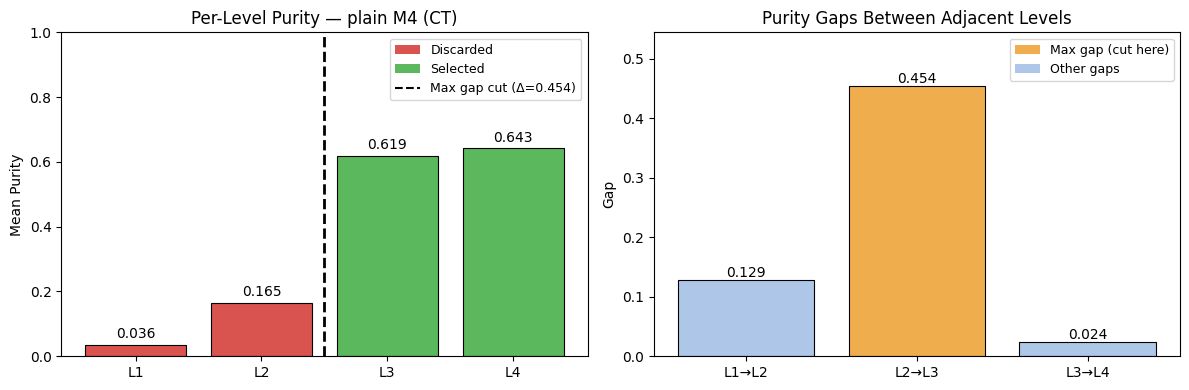

Saved: results/v8/purity_m4_plain_ct.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: bar chart of per-level purity
levels_sorted = [l for l, p in sorted_levels]
purities_sorted = [p for l, p in sorted_levels]
colors = ["#d9534f" if l in low_purity else "#5cb85c" for l in levels_sorted]

ax = axes[0]
bars = ax.bar(
    [f"L{l}" for l in levels_sorted],
    purities_sorted,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
)
ax.set_title("Per-Level Purity — plain M4 (CT)", fontsize=12)
ax.set_ylabel("Mean Purity")
ax.set_ylim(0, 1.0)
for bar, p in zip(bars, purities_sorted):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        p + 0.02,
        f"{p:.3f}",
        ha="center",
        fontsize=10,
    )

# Mark cut
cut_x = levels_sorted.index(cut_to) - 0.5
ax.axvline(cut_x, color="black", lw=2, ls="--", label=f"Max-gap cut (Δ={max_gap:.3f})")
ax.legend(fontsize=9)

from matplotlib.patches import Patch

ax.legend(
    handles=[
        Patch(facecolor="#d9534f", label="Discarded"),
        Patch(facecolor="#5cb85c", label="Selected"),
        plt.Line2D(
            [0], [0], color="black", ls="--", label=f"Max gap cut (Δ={max_gap:.3f})"
        ),
    ],
    fontsize=9,
)

# Right: gap chart
ax2 = axes[1]
gap_labels = [
    f"L{sorted_levels[i][0]}→L{sorted_levels[i + 1][0]}"
    for i in range(len(sorted_levels) - 1)
]
gap_values = [g[0] for g in gaps]
gap_colors = ["#f0ad4e" if g[1] == cut_idx else "#aec6e8" for g in gaps]
ax2.bar(gap_labels, gap_values, color=gap_colors, edgecolor="black", linewidth=0.8)
ax2.set_title("Purity Gaps Between Adjacent Levels", fontsize=12)
ax2.set_ylabel("Gap")
for i, (label, val) in enumerate(zip(gap_labels, gap_values)):
    ax2.text(i, val + 0.005, f"{val:.3f}", ha="center", fontsize=10)
ax2.set_ylim(0, max(gap_values) * 1.2)

from matplotlib.patches import Patch

ax2.legend(
    handles=[
        Patch(facecolor="#f0ad4e", label="Max gap (cut here)"),
        Patch(facecolor="#aec6e8", label="Other gaps"),
    ],
    fontsize=9,
)

plt.tight_layout()
plt.savefig(f"{LOG_DIR}/purity_m4_plain_ct.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {LOG_DIR}/purity_m4_plain_ct.png")

## 7. Stage 31 Comparison

Stage 31 used `proto_seg_ct_l1234_attn_noent.pth` (attention model) for the
same purity computation. Compare results to confirm plain M4 gives a consistent signal.

In [8]:
# Stage 31 results (from ablation notebook, attention model)
STAGE31_PURITY = {1: 0.084, 2: 0.195, 3: 0.613, 4: 0.689}

print(f"{'Level':<8} {'Stage31 (attn)':>16} {'Stage32 (plain)':>17} {'Delta':>8}")
print("─" * 52)
for l in [1, 2, 3, 4]:
    p31 = STAGE31_PURITY[l]
    p32 = purity_per_level.get(l, float("nan"))
    delta = p32 - p31
    tag = " ← low" if l in low_purity else " ← kept"
    print(f"L{l:<7} {p31:>16.3f} {p32:>17.3f} {delta:>+8.3f}{tag}")

print()
print("Note: Positive delta = plain M4 shows higher purity for this level.")
print(
    "Negative delta = attention model artificially inflated purity (L2 feedback loop)"
)

Level      Stage31 (attn)   Stage32 (plain)    Delta
────────────────────────────────────────────────────
L1                  0.084             0.036   -0.048 ← low
L2                  0.195             0.165   -0.030 ← low
L3                  0.613             0.619   +0.006 ← kept
L4                  0.689             0.643   -0.046 ← kept

Note: Positive delta = plain M4 shows higher purity for this level.
Negative delta = attention model artificially inflated purity (L2 feedback loop)


## 8. Summary Table

In [9]:
summary_rows = []
for l in sorted(purity_per_level):
    p = purity_per_level[l]
    p31 = STAGE31_PURITY.get(l, float("nan"))
    summary_rows.append(
        {
            "level": l,
            "purity_plain_m4": round(p, 4),
            "purity_attn_m4": p31,
            "delta": round(p - p31, 4),
            "selected": l in high_purity,
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(f"{LOG_DIR}/purity_m4_plain_ct.csv", index=False)

print(summary_df.to_string(index=False))
print(f"\nSaved: {LOG_DIR}/purity_m4_plain_ct.csv")

print(f"\nCheckpoint acceptance: 3D Dice = {overall_3d:.4f} ≥ {MIN_3D_DICE} ✅")
print(
    f"Max-gap cut: between L{cut_from} (purity={purity_per_level[cut_from]:.3f}) "
    f"and L{cut_to} (purity={purity_per_level[cut_to]:.3f}), gap={max_gap:.3f}"
)
print(f"Selected levels: {sorted(high_purity)}")

 level  purity_plain_m4  purity_attn_m4   delta  selected
     1           0.0357           0.084 -0.0483     False
     2           0.1648           0.195 -0.0302     False
     3           0.6186           0.613  0.0056      True
     4           0.6429           0.689 -0.0461      True

Saved: results/v8/purity_m4_plain_ct.csv

Checkpoint acceptance: 3D Dice = 0.8341 ≥ 0.82 ✅
Max-gap cut: between L2 (purity=0.165) and L3 (purity=0.619), gap=0.454
Selected levels: [3, 4]


## 9. RQ13 Verdict

In [10]:
print("RQ13: Does the max-gap filter on plain M4 purity correctly and automatically")
print("      select L3+L4, without any hardcoded threshold?")
print()

criteria = [
    (f"Plain M4 3D Dice ≥ {MIN_3D_DICE}", ok_dice),
    ("Max-gap filter selects exactly {L3, L4}", ok_selection),
    (
        f"Max gap at L{cut_from}→L{cut_to} (L2→L3 boundary)",
        cut_from == 2 and cut_to == 3,
    ),
    (f"Max gap magnitude > 0.3 (clear separation)", max_gap > 0.3),
]

passed = sum(1 for _, ok in criteria if ok)
for desc, ok in criteria:
    print(f"  {'✅' if ok else '❌'}  {desc}")

print()
print(f"Result: {passed}/{len(criteria)} criteria met")
print()

if passed == len(criteria):
    print("Verdict: RQ13 MET — Max-gap filter correctly auto-selects L3+L4.")
    print(
        f"  Gap distribution: L1={purity_per_level[1]:.3f} L2={purity_per_level[2]:.3f} "
        f"L3={purity_per_level[3]:.3f} L4={purity_per_level[4]:.3f}"
    )
    print(
        f"  Max gap at L2→L3 = {max_gap:.3f} (> {gaps[1][0]:.3f} and {gaps[2][0]:.3f})"
    )
    print()
    print("→ Proceed to Stage 33: ALC implementation")
    print("→ Phase 2 encoder warm-start: use this checkpoint (proto_seg_ct_pp2.pth)")
elif ok_selection:
    print("Verdict: RQ13 PARTIAL — correct selection, but some criteria not met.")
    print("→ Investigate which criterion failed before proceeding.")
else:
    print(
        f"Verdict: RQ13 NOT MET — filter selected {sorted(high_purity)}, expected [3, 4]."
    )
    print("→ Investigate purity distribution; may need to retrain plain M4.")

RQ13: Does the max-gap filter on plain M4 purity correctly and automatically
      select L3+L4, without any hardcoded threshold?

  ✅  Plain M4 3D Dice ≥ 0.82
  ✅  Max-gap filter selects exactly {L3, L4}
  ✅  Max gap at L2→L3 (L2→L3 boundary)
  ✅  Max gap magnitude > 0.3 (clear separation)

Result: 4/4 criteria met

Verdict: RQ13 MET — Max-gap filter correctly auto-selects L3+L4.
  Gap distribution: L1=0.036 L2=0.165 L3=0.619 L4=0.643
  Max gap at L2→L3 = 0.454 (> 0.454 and 0.024)

→ Proceed to Stage 33: ALC implementation
→ Phase 2 encoder warm-start: use this checkpoint (proto_seg_ct_pp2.pth)
